In [1]:
from dummy_spatialdata import generate_dataset
import dummy_anndata
import spatialdata_plot as sdp 
import spatialdata as sd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad
import tempfile as tf

/Users/amanuky/miniforge3/envs/dummy_sd_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
adata = dummy_anndata.generate_dataset(n_obs=12, n_vars=20)

sdata = generate_dataset(
    images = [
        {"type": "rgb", "n_layers": 4, "coordinate_system": "global"},
        {"type": "grayscale", "n_layers": 1, "coordinate_system": "global"},
    ],
    labels = [
        {"n_labels": 12, "n_layers": 4, "coordinate_system": "global2"},
        {"n_labels": 12, "n_layers": 0, "coordinate_system": "global2"},
    ], 
    shapes = [
        {"n_shapes": 12, "coordinate_system": "global"},
        {"n_shapes": 20},
    ],
    points = [
        {"n_points": 12}
    ],
    tables = [
        {"table": adata, "element": "shape", "element_index": 0}
    ],
    coordinate_systems = {
        "global": {"transformations": ["affine"], "shape": {"x": 2000, "y": 2000}},
        "global2": {"transformations": ["scale", "translation"], "shape":{"x": 500, "y": 500}}
    },
    SEED=13
)
sdata

# write to temp
filename = tf.NamedTemporaryFile()
filename.name + ".zarr"
sdata.write(filename.name + ".zarr")

# read back
sd.read_zarr(filename.name + ".zarr")

/Users/amanuky/miniforge3/envs/dummy_sd_env/lib/python3.14/site-packages/spatialdata/models/models.py:1235: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)


SpatialData object, with associated Zarr store: /private/var/folders/vf/d8kg507x41xfh6z9vgv9skksdsn29w/T/tmp9xr_r4m0.zarr
├── Images
│     ├── 'image_0': DataTree[cyx] (3, 2000, 2000), (3, 1000, 1000), (3, 500, 500), (3, 250, 250)
│     └── 'image_1': DataArray[cyx] (1, 2000, 2000)
├── Labels
│     ├── 'label_0': DataTree[yx] (500, 500), (250, 250), (125, 125), (62, 62)
│     └── 'label_1': DataArray[yx] (500, 500)
├── Points
│     └── 'point_0': DataFrame with shape: (<Delayed>, 2) (2D points)
├── Shapes
│     ├── 'shape_0': GeoDataFrame shape: (12, 1) (2D shapes)
│     └── 'shape_1': GeoDataFrame shape: (20, 1) (2D shapes)
└── Tables
      └── 'table_0': AnnData (12, 20)
with coordinate systems:
    ▸ 'global', with elements:
        image_0 (Images), image_1 (Images), shape_0 (Shapes)
    ▸ 'global2', with elements:
        label_0 (Labels), label_1 (Labels)
    ▸ 'point_0', with elements:
        point_0 (Points)
    ▸ 'shape_1', with elements:
        shape_1 (Shapes)

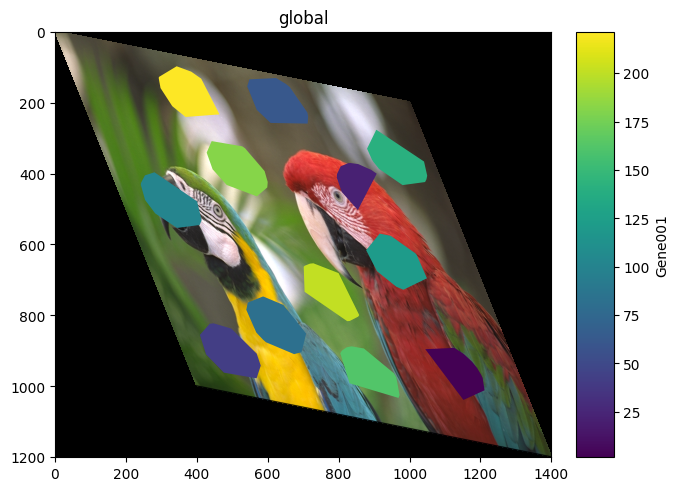

In [12]:
sdata.pl.render_images("image_0").pl.render_shapes("shape_0", color="Gene001", table_name = "table_0", table_layer = "float_matrix").pl.show(coordinate_systems = "global")